<a href="https://colab.research.google.com/github/pratikchopade21-a11y/IPCV-Lab/blob/main/IPCV_Exp__10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Name:-Pratik Mahesh Chopade
#Roll No.:- TY AIML B59
#PRN:- 2324001102
#IPCV Lab Exp. 10:-COVID-19 Detection using VGGNet

In [ ]:
!pip install tensorflow matplotlib seaborn scikit-learn opencv-python kaggle

In [ ]:
# Create the .kaggle directory and move the uploaded JSON file to it
!mkdir -p ~/.kaggle
!cp "/content/kaggle (1).json" ~/.kaggle/kaggle.json

# Set the correct permissions so the API can read it
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle credentials set up successfully.")

cp: cannot stat '/content/kaggle (1).json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle credentials set up successfully.


In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"pratik212500","key":"5d9f936d3209f83c030df1cdf1d5a88e"}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:19<00:00, 42.5MB/s]



In [ ]:
!unzip covid19-radiography-database.zip -d covid_dataset

Streaming output truncated to the last 5000 lines.
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: covid_dataset/COVID-19_Radiography_Dataset/Normal/masks/Normal-7930

In [ ]:
import os

dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

print(os.listdir(dataset_path))

['Normal.metadata.xlsx', 'Lung_Opacity.metadata.xlsx', 'Viral Pneumonia', 'Viral Pneumonia.metadata.xlsx', 'Lung_Opacity', 'COVID.metadata.xlsx', 'Normal', 'COVID', 'README.md.txt']


In [ ]:
dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#Create Binary Dataset: COVID vs Normal
source_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

covid_source = os.path.join(source_path, "COVID", "images")
normal_source = os.path.join(source_path, "Normal", "images")

base_dir = "/content/covid_binary_dataset"
covid_target = os.path.join(base_dir, "COVID")
normal_target = os.path.join(base_dir, "Normal")

os.makedirs(covid_target, exist_ok=True)
os.makedirs(normal_target, exist_ok=True)

max_images = 3000

covid_images = os.listdir(covid_source)[:max_images]
normal_images = os.listdir(normal_source)[:max_images]

for img in covid_images:
    shutil.copy(os.path.join(covid_source, img), os.path.join(covid_target, img))

for img in normal_images:
    shutil.copy(os.path.join(normal_source, img), os.path.join(normal_target, img))

print("COVID images:", len(os.listdir(covid_target)))
print("Normal images:", len(os.listdir(normal_target)))

COVID images: 3000
Normal images: 3000


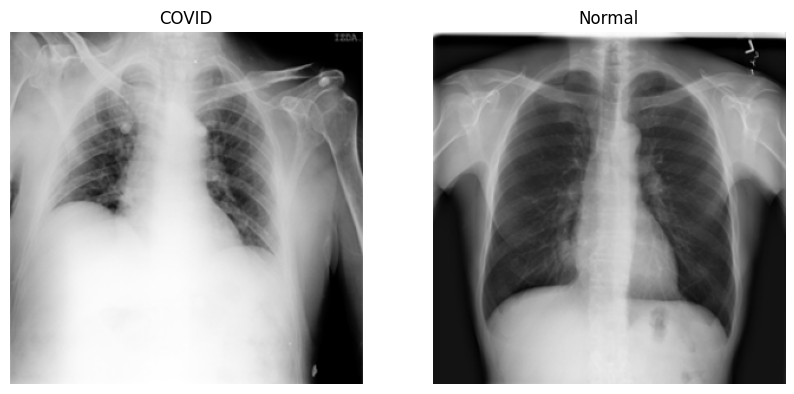

In [ ]:
# Display Sample Images
classes = ["COVID", "Normal"]

plt.figure(figsize=(10, 5))

for i, cls in enumerate(classes):
    folder = os.path.join(base_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
#Image Preprocessing and Data Augmentation
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print(train_generator.class_indices)

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
{'COVID': 0, 'Normal': 1}


In [ ]:
# Build VGG16 Model
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
base_model = VGG16(...)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#Train the Model
checkpoint = ModelCheckpoint(
    "best_vgg_covid_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.8263 - loss: 0.3933
Epoch 1: val_accuracy improved from None to 0.89583, saving model to best_vgg_covid_model.h5



Epoch 1: finished saving model to best_vgg_covid_model.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 113s 755ms/step - accuracy: 0.8265 - loss: 0.3938 - val_accuracy: 0.8958 - val_loss: 0.2659 - learning_rate: 1.0000e-04
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.8381 - loss: 0.3567
Epoch 2: val_accuracy did not improve from 0.89583
150/150 ━━━━━━━━━━━━━━━━━━━━ 105s 697ms/step - accuracy: 0.8406 - loss: 0.3537 - val_accuracy: 0.8933 - val_loss: 0.2572 - learning_rate: 1.0000e-04
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.8428 - loss: 0.3480
Epoch 3: val_accuracy improved from 0.89583 to 0.91083, saving model to best_vgg_covid_model.h5



Epoch 3: finished saving model to best_vgg_covid_model.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 106s 704ms/step - accuracy: 0.8531 - loss: 0.3320 - val_accuracy: 0.9108 - val_loss: 0.2367 - learning_rate: 1.0000e-04
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8571 - loss: 0.3183
Epoch 4: val_accuracy improved from 0.91083 to 0.91417, saving model to best_vgg_covid_model.h5



Epoch 4: finished saving model to best_vgg_covid_model.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 106s 708ms/step - accuracy: 0.8654 - loss: 0.3062 - val_accuracy: 0.9142 - val_loss: 0.2160 - learning_rate: 1.0000e-04
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.8697 - loss: 0.3078
Epoch 5: val_accuracy improved from 0.91417 to 0.91667, saving model to best_vgg_covid_model.h5



Epoch 5: finished saving model to best_vgg_covid_model.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 106s 707ms/step - accuracy: 0.8685 - loss: 0.3044 - val_accuracy: 0.9167 - val_loss: 0.2264 - learning_rate: 1.0000e-04


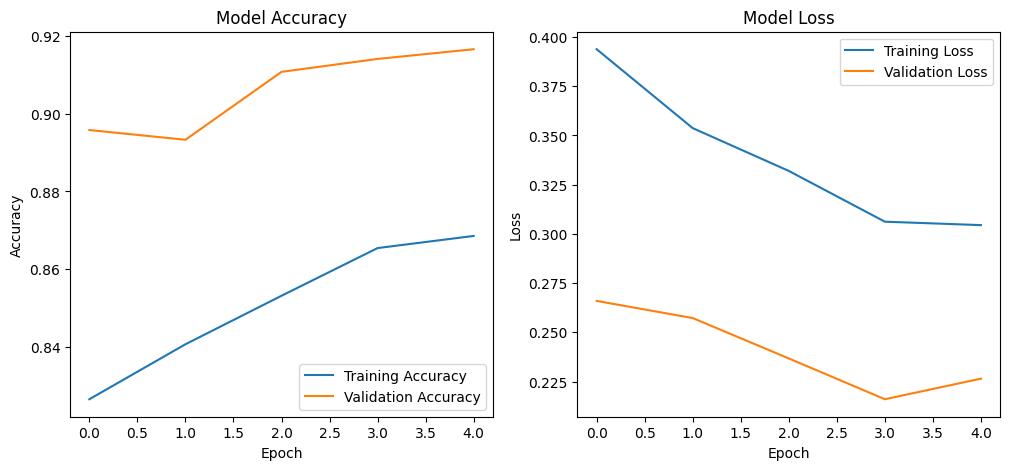

In [ ]:
#Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
#Evaluate Model
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

accuracy = accuracy_score(true_classes, predicted_classes)

print("Accuracy:", accuracy)
print()
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 659ms/step
Accuracy: 0.9133333333333333

              precision    recall  f1-score   support

       COVID       0.92      0.91      0.91       600
      Normal       0.91      0.92      0.91       600

    accuracy                           0.91      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.91      0.91      0.91      1200



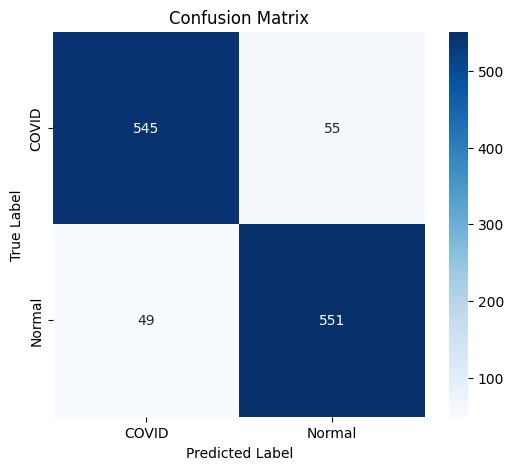

In [ ]:
#Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Test on a Single X-ray Image
from tensorflow.keras.preprocessing import image

def predict_xray(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Normal"
        confidence = prediction
    else:
        label = "COVID"
        confidence = 1 - prediction

    print("Prediction:", label)
    print("Confidence:", round(confidence * 100, 2), "%")

    plt.imshow(image.load_img(img_path))
    plt.title(f"{label} ({confidence * 100:.2f}%)")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: COVID
Confidence: 98.1 %


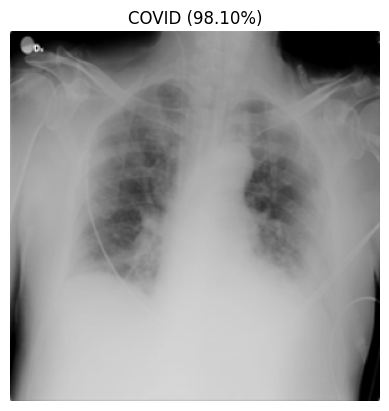

In [ ]:
test_image = "/content/covid_binary_dataset/COVID/COVID-1.png"
predict_xray(test_image)

In [ ]:
#Save the Model
model.save("covid_vgg16_model.h5")

In [ ]:
loaded_model = tf.keras.models.load_model("covid_vgg16_model.h5")

In [ ]:
# Fine-Tuning VGG16
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8734 - loss: 0.2935
Epoch 1: val_accuracy improved from 0.91667 to 0.92083, saving model to best_vgg_covid_model.h5



Epoch 1: finished saving model to best_vgg_covid_model.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 113s 731ms/step - accuracy: 0.8687 - loss: 0.3024 - val_accuracy: 0.9208 - val_loss: 0.2151 - learning_rate: 1.0000e-05
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.8665 - loss: 0.3148
Epoch 2: val_accuracy did not improve from 0.92083
150/150 ━━━━━━━━━━━━━━━━━━━━ 108s 718ms/step - accuracy: 0.8721 - loss: 0.3029 - val_accuracy: 0.9142 - val_loss: 0.2218 - learning_rate: 1.0000e-05
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.8775 - loss: 0.2881
Epoch 3: val_accuracy did not improve from 0.92083
150/150 ━━━━━━━━━━━━━━━━━━━━ 105s 700ms/step - accuracy: 0.8779 - loss: 0.2897 - val_accuracy: 0.9125 - val_loss: 0.2179 - learning_rate: 1.0000e-05
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8813 - loss: 0.2764
Epoch 4: val_accuracy did not improve from 0.92083

Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
15

In [ ]:
#Grad-CAM Visualization
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [ ]:
#Apply Grad-CAM:
def display_gradcam(img_path, model, last_conv_layer_name="block5_conv3"):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = preprocess_input(img_array_expanded)

    heatmap = make_gradcam_heatmap(
        img_array_preprocessed,
        model,
        last_conv_layer_name
    )

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


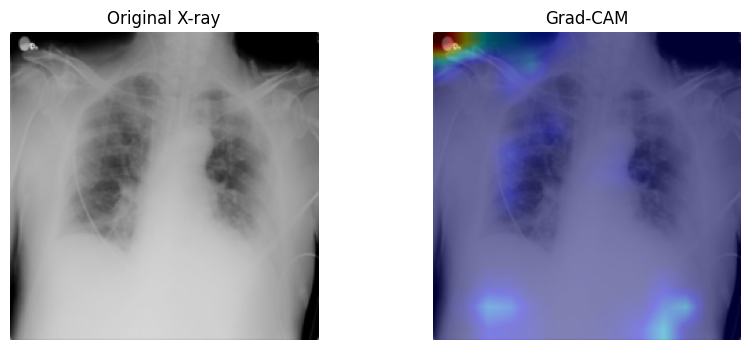

In [ ]:
#Example:-
display_gradcam(test_image, model)